## TD N°2 explicabilité du dataset Boston Housing

1) Charger le dataset bostong_housing
   1) Disponible dans le folder data/
   
2) Nettoyer votre jeu de données pour créer une régression linéaire et un random forest
   1) Tester d'ajouter des features log, quadratique, ...

3) Créer un modèle baseline linéaire et random forest

4) Interpréter le modèle linéaire

5) Tuner votre random forest

6) Interpréter globalement votre modèle meilleur modèle RF 
   1) Utiliser les PDP ou ALE & Permutation feature Importance 
   2) Comparer les résulats du random forest avec votre interprétation du modèle linéaire

6) Réaliser une explicabilité par individu
   1) En utilisant la méthode ICE (PDP individuelle)
   2) LIME (Model local pour expliquer une prédiction)
   3) SHAP watterfall plot (Contribution marginale de chaque variable dans la prédiction)

7) Réaliser une explicabilité par individu sur le modèle RF
- 1) ICE, le PDP est-il une bonne représentation des variables importantes de votre modèle?
- 2) LIME
- 3) SHAP watterfall plot

8) Explorer les graphiques SHAP étudiés  dans la partie CM
   1) beeswarm (Contribution des variables)
   2) scatter (équivalent pdp)

## Contexte du Dataset

Le Boston Housing Dataset est un ensemble de données couramment utilisé en apprentissage automatique et en statistique pour étudier les relations entre diverses caractéristiques socio-économiques et immobilières dans la ville de Boston.  
Il contient des informations sur des propriétés résidentielles et leur environnement, et est souvent utilisé pour prédire la valeur des maisons, un problème classique de régression.

**Variable dispo**: 
- CRIM : taux de criminalité par habitant par ville
- ZN : proportion de terrains résidentiels zonés pour des lots de plus de 25 000 pieds carrés
- INDUS : proportion de terrains commerciaux non commerciaux par ville
- CHAS : variable binaire indiquant la proximité de la rivière Charles (= 1 si la zone délimitée par la ville touche la rivière ; 0 sinon)
- NOX : concentration des oxydes d'azote (en parties par 10 millions)
- RM : nombre moyen de pièces par logement
- AGE : proportion des unités occupées par leur propriétaire et construites avant 1940
- DIS : distances pondérées vers cinq centres d'emploi de Boston
- RAD : indice d'accessibilité aux autoroutes radiales
- TAX : taux d'imposition foncière par valeur totale pour chaque tranche de 10 000 dollars
- PTRATIO : ratio élèves-enseignants par ville
- LSTAT : pourcentage de la population de statut socio-économique inférieur
- MEDV : valeur médiane des maisons occupées par leur propriétaire (en milliers de dollars) - **variable cible**

In [1]:
# ==========================
# Gestion des données
# ==========================
import pandas as pd
import numpy as np

# ==========================
# Visualisation
# ==========================
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================
# Prétraitement et modèles
# ==========================
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
import statsmodels.api as sm

# ==========================
# Explicabilité
# ==========================
from alibi.explainers import ALE, plot_ale
import lime
import lime.lime_tabular
from IPython.display import HTML
import shap

import warnings
warnings.filterwarnings('ignore')

c:\Users\flori\Documents\Florian\21. University\1. Master\MASTER 2\SVM et réseaux de neurones\Python\dossier\master-year2-svm-and-neural-networks\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1) Charger le dataset bostong_housing

In [2]:
# Charger le fichier local situé dans le dossier data/
df = pd.read_csv('data/boston_housing.csv', sep=';', index_col=0)

In [3]:
# Afficher les 5 premières lignes du DataFrame
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,5.33,36.2


### 2) Nettoyer votre jeu de données pour créer une régression linéaire et un random forest

Pensez à :

- Vérifier comment encoder vos variables qualitatives pour la modélisation 
- Analyser les distributions
- Analyser les outliers 
- Analyser les corrélations

>Testez l'ajout de features log, quadratiques, ...

#### 2.1) Vérifier comment encoder vos variables qualitatives pour la modélisation

In [4]:
# Vérifier le type des données (et les éventuelles valeurs manquantes)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  LSTAT    506 non-null    float64
 12  MEDV     506 non-null    float64
dtypes: float64(11), int64(2)
memory usage: 51.5 KB


**Observations sur les données :**
- **Valeurs manquantes** : Le dataset est parfaitement propre, il n'y a aucune valeur manquante (`506 non-null` pour chaque colonne sur un total de 506 entrées). Aucune imputation n'est nécessaire.
- **Type de données** : Toutes les variables sont déjà encodées sous forme numérique (`float64` ou `int64`). Même la variable qualitative `CHAS` (proximité de la rivière) est déjà encodée en binaire (0 ou 1). Nous n'avons donc pas besoin d'appliquer de `OneHotEncoder` ou d'`OrdinalEncoder`. Le dataset est prêt pour la modélisation.

#### 2.2) Analyser les distributions

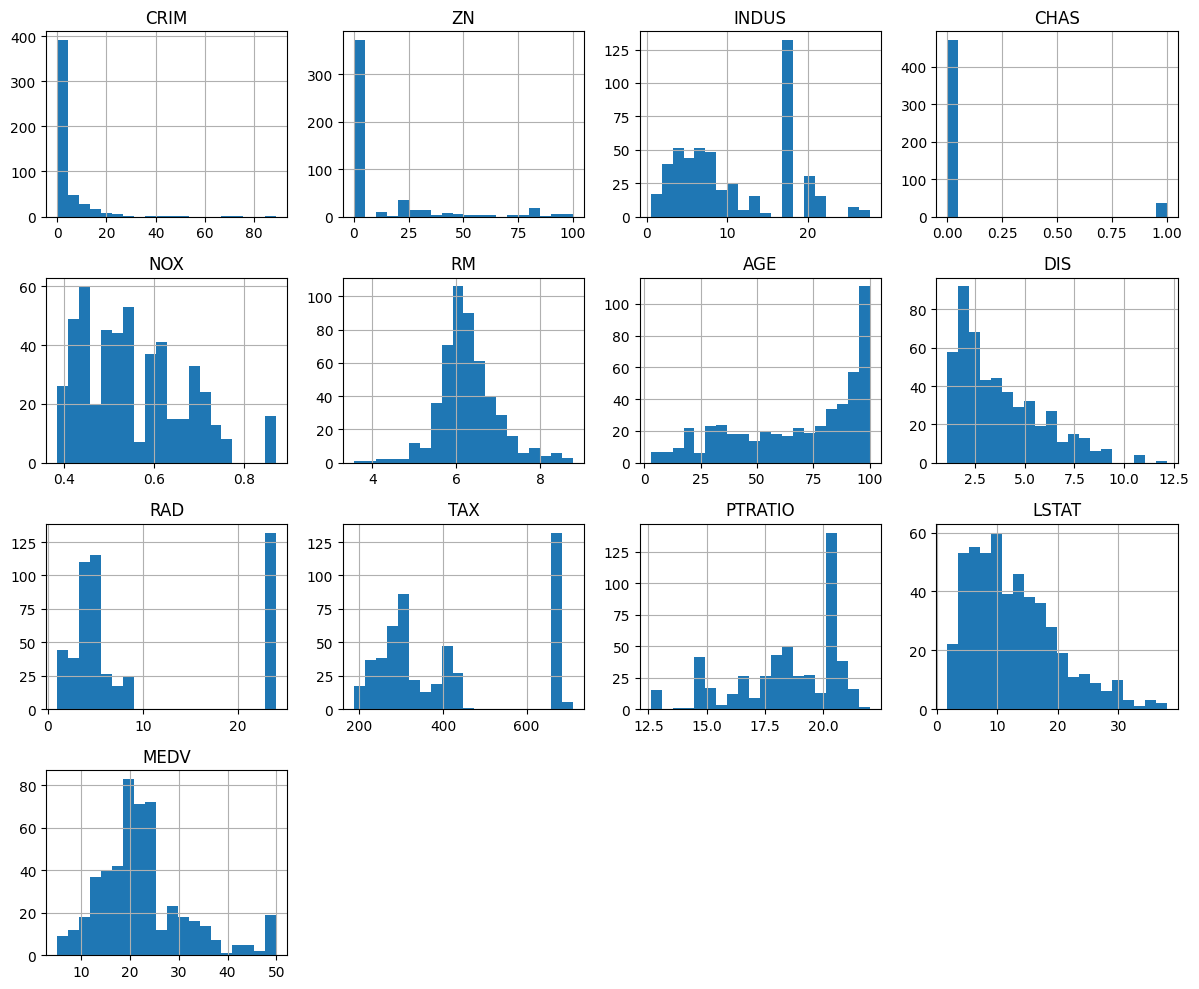

In [5]:
# Analyser la distribution de toutes les variables du dataframe
df.hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()

**Observations sur les distributions :**
- **Variables asymétriques à droite** (avec une longue traîne) : `CRIM`, `ZN`, `DIS`, `LSTAT`. Il faudra sûrement appliquer une transformation logarithmique ou racine carrée pour ces variables afin de les normaliser pour la régression linéaire.
- **Variables bimodales / multimodales** : `INDUS`, `RAD`, `TAX`. Ces variables semblent séparer la population en groupes distincts.
- **Variables binaires ou discrètes** : `CHAS` est clairement binaire (proche rivière ou non). `RAD` et `TAX` comportent des valeurs très concentrées, presque discrètes.
- **Variables proches de la normale** : `RM` (nombre de pièces) et dans une moindre mesure notre cible `MEDV` présentent une distribution en cloche, bien que `MEDV` ait un pic anormal à la valeur maximale (50k$), suggérant un plafonnement (capping) dans la collecte des données qu'il faudra surveiller.

#### 2.3) Analyser les outliers 

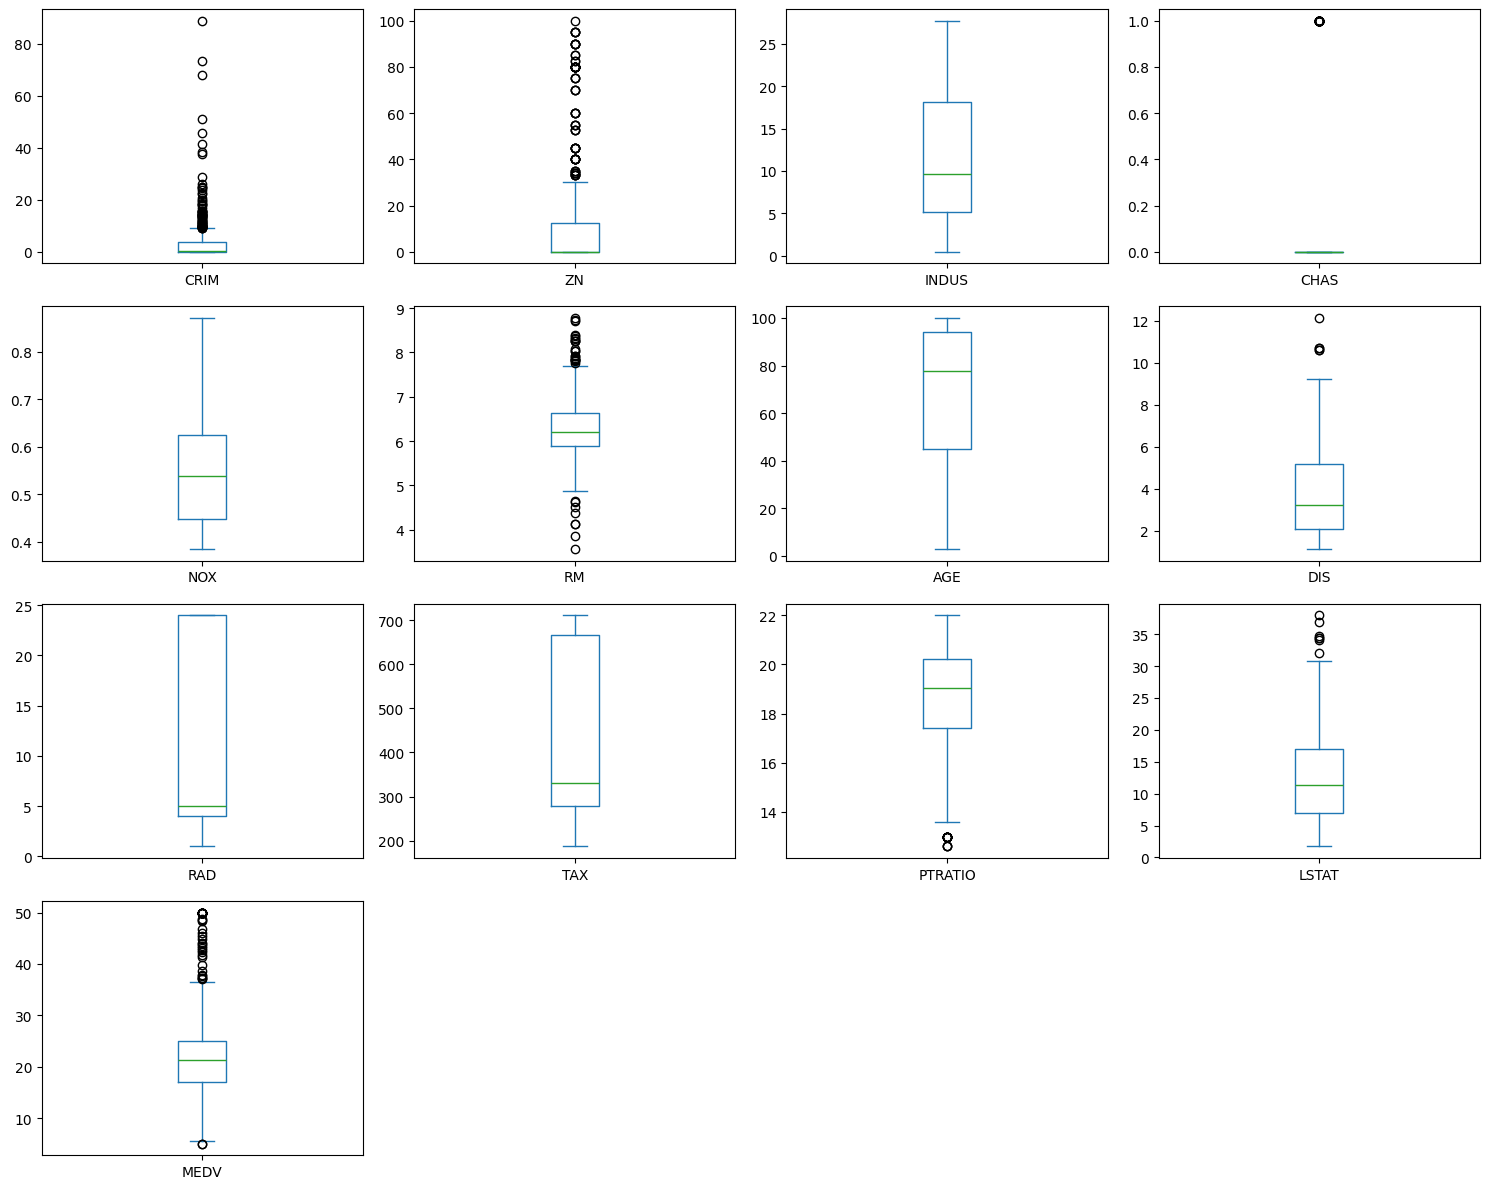

In [6]:
# Analyser les outliers avec des boîtes à moustaches (boxplots)
df.plot(kind='box', subplots=True, layout=(4, 4), figsize=(15, 12), sharex=False, sharey=False)
plt.tight_layout()
plt.show()

**Observations sur les outliers :**
- **Variables très affectées par les outliers** : `CRIM` (taux de criminalité) et `ZN` présentent de nombreuses valeurs extrêmes très éloignées de la médiane, ce qui confirme leur distribution très asymétrique (longue traîne à droite). Ces valeurs fausseront la régression linéaire et devront être transformées.
- **Variables modérément affectées** : `RM` (nombre de pièces), `LSTAT` et `MEDV` présentent quelques points en dehors des moustaches, mais cela semble correspondre à la variabilité naturelle de l'immobilier de luxe ou des quartiers très défavorisés.
- **Le cas de MEDV (Cible)** : Les nombreux points au-delà du seuil supérieur de la boîte (notamment le cap à 50k$) pourraient perturber le modèle linéaire, qui y sera très sensible contrairement au Random Forest.
- **Variables sans outliers majeurs** : `INDUS`, `NOX`, `AGE`, `RAD` et `TAX` ont l'essentiel de leurs valeurs contenues dans les moustaches.

#### 2.4) Réaliser une analyse bivariée (Diagnostic de Transformation)
Vérifions visuellement l'intérêt d'une transformation logarithmique ou polynomiale par rapport à une relation linéaire classique.

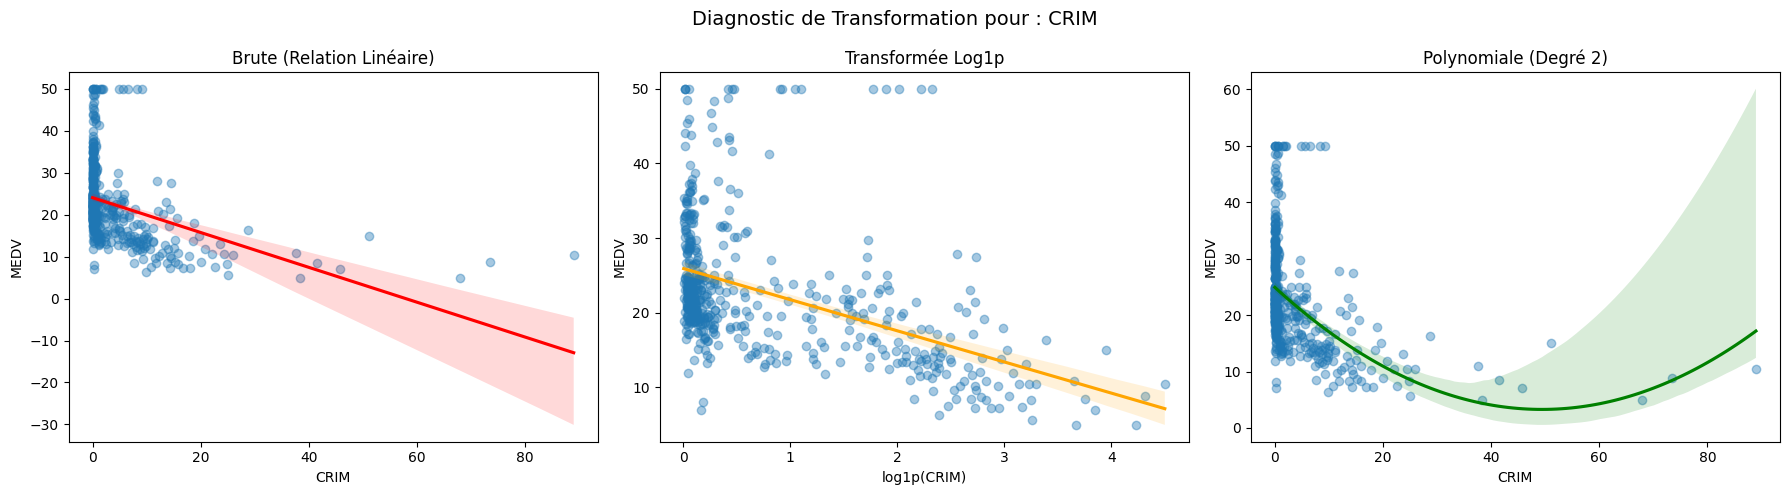

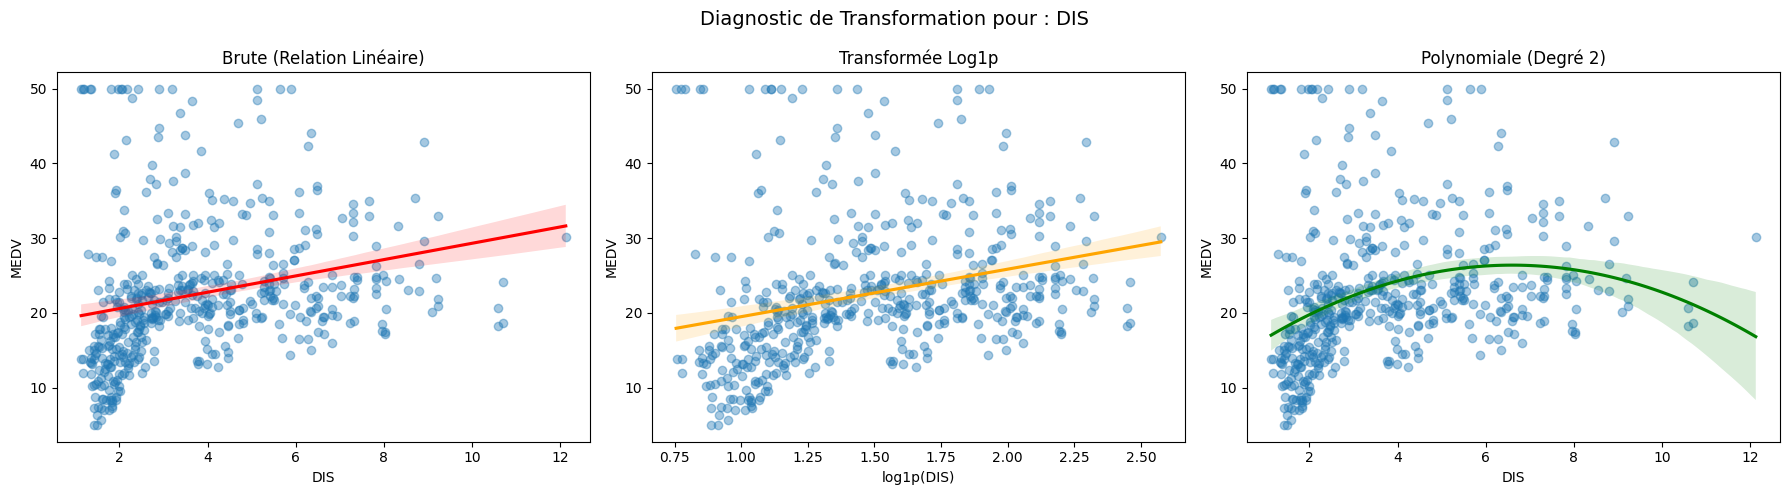

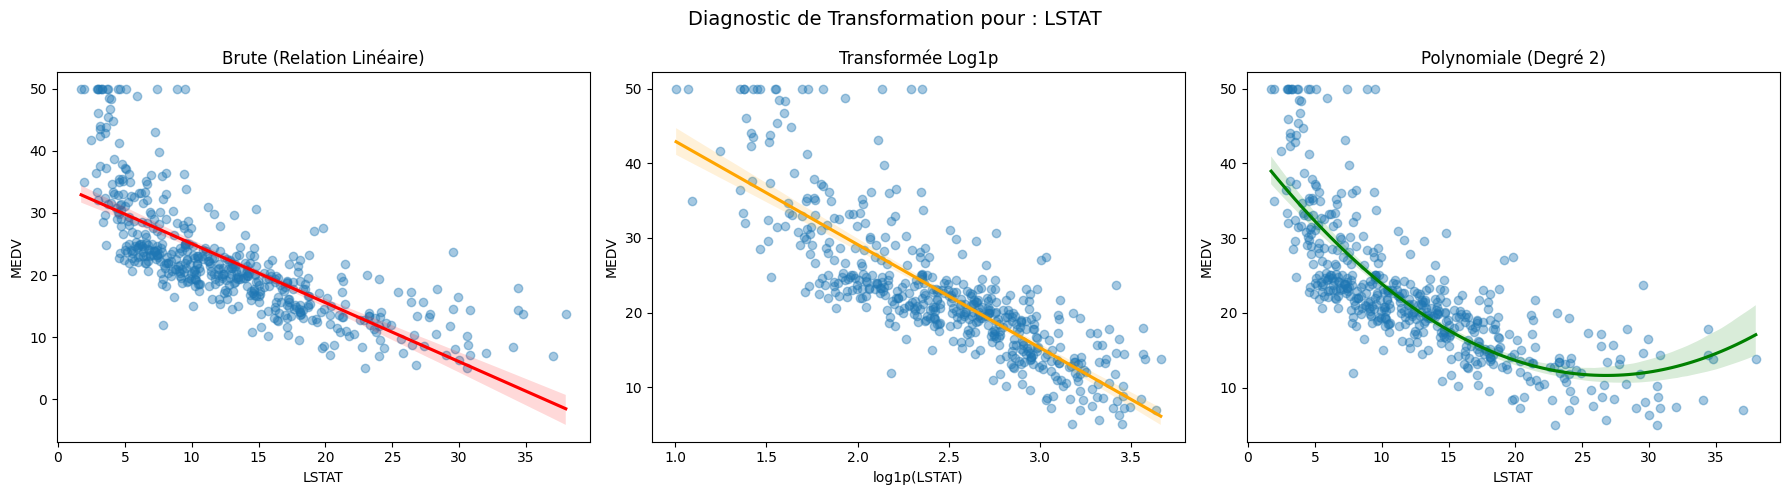

In [7]:
# Sélectionner les variables continues fortement asymétriques
vars_to_test = ['CRIM', 'DIS', 'LSTAT']

for col in vars_to_test:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Diagnostic de Transformation pour : {col}', fontsize=14)

    # 1. Relation Linéaire Brute avec MEDV
    sns.regplot(ax=axes[0], data=df, x=col, y='MEDV', 
                scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
    axes[0].set_title('Brute (Relation Linéaire)')

    # 2. Relation Logarithmique avec MEDV
    log_data = np.log1p(df[col])
    sns.regplot(ax=axes[1], x=log_data, y=df['MEDV'], 
                scatter_kws={'alpha':0.4}, line_kws={'color':'orange'})
    axes[1].set_title('Transformée Log1p')
    axes[1].set_xlabel(f'log1p({col})')

    # 3. Relation Quadratique avec MEDV (Degré 2)
    sns.regplot(ax=axes[2], data=df, x=col, y='MEDV', order=2, 
                scatter_kws={'alpha':0.4}, line_kws={'color':'green'})
    axes[2].set_title('Polynomiale (Degré 2)')

    plt.tight_layout()
    plt.show()

**Observations sur le diagnostic de transformation :**
Les graphiques montrent que l'application d'un logarithme `log1p()` sur les variables asymétriques permet de "redresser" la relation avec la cible `MEDV`. Les points s'alignent mieux autour de la droite de régression (orange) que sur les données brutes (rouge), réduisant ainsi l'impact d'une variance inégale. La transformation polynomiale (verte) confirme que la relation entre `LSTAT` et `MEDV` n'est pas strictement linéaire, mais le passage au log s'avère suffisant et plus simple à interpréter pour notre futur modèle de régression linéaire.

#### 2.5) Analyser les corrélations

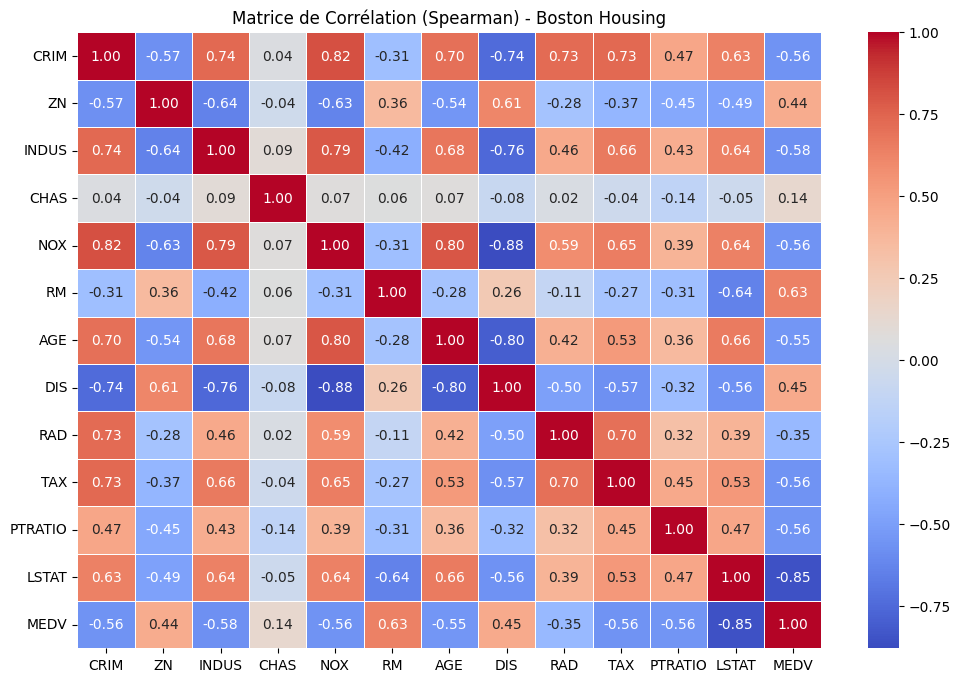

In [8]:
# Analyser les corrélations avec la méthode de Spearman (adaptée aux distributions asymétriques)
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(method='spearman'), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matrice de Corrélation (Spearman) - Boston Housing')
plt.show()

**Observations sur les corrélations (Spearman) :**
- **Corrélations avec la cible (MEDV)** : La variable la plus positivement corrélée au prix est le nombre de pièces (`RM` = 0.63). À l'inverse, le statut socio-économique (`LSTAT` = -0.85) a une très forte corrélation négative avec le prix (plus forte encore qu'en Pearson). La criminalité (`CRIM` = -0.56) et la pollution (`NOX` = -0.56) pèsent également négativement.
- **Multicollinéarité (risques pour la régression linéaire)** : 
  - `RAD` (accès aux autoroutes) et `TAX` (impôts fonciers) ont une corrélation de rang quasi-parfaite (0.70).
  - `NOX` (pollution) est extrêmement corrélé avec `INDUS` (0.79) et `AGE` (0.80), et négativement avec `DIS` (-0.88).
  - `DIS` (distance aux centres d'emploi) est logiquement très corrélé négativement avec `AGE` (-0.80) et `INDUS` (-0.76).
  - `CRIM` est très fortement corrélé à `NOX` (0.82).

#### 2.6) Créer de nouvelles features et séparer le jeu de données (Train/Test)
- **Feature Engineering** : On crée de nouvelles variables d'interaction (`LSTAT` au carré, `RM` au carré, croisement `INDUS`*`NOX`, etc.) pour aider le modèle linéaire à capter des effets complexes. Ces calculs mathématiques purs peuvent être faits avant le split.
- **Séparation (Data Leakage)** : ⚠️ Il faut séparer les données **avant** toute transformation statistique. Les règles de standardisation se calculent (`.fit()`) uniquement sur le jeu d'entraînement, puis s'appliquent (`.transform()`) sur le jeu de test.

In [9]:
# Créer de nouvelles variables d'interaction et polynomiales (Feature Engineering)
# Appliquer ces transformations AVANT le split car elles sont déterministes ligne par ligne et ne créent pas de fuite
df_fe = df.copy()
df_fe['LSTAT_sq'] = df_fe['LSTAT'] ** 2
df_fe['RM_sq'] = df_fe['RM'] ** 2
df_fe['INDUS_NOX'] = df_fe['INDUS'] * df_fe['NOX']
df_fe['RAD_DIS'] = df_fe['RAD'] / (df_fe['DIS'] + 1e-5)

# Séparer les features (X) de la cible (y)
X = df_fe.drop(columns=['MEDV'])
y = df_fe['MEDV']

# Diviser le dataset (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dimensions de X_train : {X_train.shape}")
print(f"Dimensions de X_test : {X_test.shape}")

Dimensions de X_train : (404, 16)
Dimensions de X_test : (102, 16)


#### 2.7) Transformer les variables
Au vu de notre analyse exploratoire, voici les transformations à effectuer sur nos jeux de données (toujours **après** la séparation Train/Test) :

- **Corriger l'asymétrie (`CRIM`, `ZN`, `DIS`, `LSTAT`)** : On utilise une transformation logarithmique (`np.log1p()`) pour atténuer l'effet des valeurs extrêmes et tendre vers une distribution normale, ce qui aide grandement la régression linéaire.
- **Gérer la multicollinéarité (`RAD`, `TAX`, `NOX`)** : `RAD` et `TAX` étant presque parfaitement corrélées, et `NOX` étant très liée à plusieurs autres variables, nous allons retirer `TAX` et `NOX` pour stabiliser les coefficients du modèle linéaire. (Le *Random Forest*, quant à lui, n'a pas besoin de ce nettoyage).
- **Mettre à l'échelle (StandardScaler)** : C'est une étape indispensable pour la régression linéaire afin de rendre les variables comparables. On va standardiser toutes les variables continues, en prenant soin d'exclure notre variable binaire `CHAS`.
- **Note sur la cible (`MEDV`)** : Son plafonnement artificiel à 50k$ est identifié, mais pour nos modèles *baselines*, nous allons laisser la cible de prix brute et intacte.

In [10]:
# Copier les jeux de données pour ne pas écraser les données brutes
X_train_lr = X_train.copy()
X_test_lr = X_test.copy()

# 1. Gérer la Multicollinéarité (Retirer TAX et NOX pour la régression linéaire)
cols_to_drop = ['TAX', 'NOX']
X_train_lr = X_train_lr.drop(columns=cols_to_drop)
X_test_lr = X_test_lr.drop(columns=cols_to_drop)

# 2. Appliquer une transformation logarithmique sur les variables asymétriques
skewed_cols = ['CRIM', 'ZN', 'DIS', 'LSTAT']
for col in skewed_cols:
    X_train_lr[col] = np.log1p(X_train_lr[col])
    X_test_lr[col] = np.log1p(X_test_lr[col])

# 3. Mettre à l'échelle (StandardScaler) - en excluant la variable binaire CHAS
scaler = StandardScaler()
cols_to_scale = [col for col in X_train_lr.columns if col != 'CHAS']

# Apprendre (fit) sur le Train, et appliquer (transform) sur le Train ET le Test
X_train_lr[cols_to_scale] = scaler.fit_transform(X_train_lr[cols_to_scale])
X_test_lr[cols_to_scale] = scaler.transform(X_test_lr[cols_to_scale])

# Afficher le résultat pour vérification
X_train_lr.head()

,CRIM,ZN,INDUS,CHAS,RM,AGE,DIS,RAD,PTRATIO,LSTAT,LSTAT_sq,RM_sq,INDUS_NOX,RAD_DIS
477,1.934774,-0.601169,1.033237,0,-1.428069,1.028015,-0.832280,1.706891,0.845343,1.473705,1.782134,-1.323752,0.857596,1.375686
15,-0.316884,-0.601169,-0.413160,0,-0.680087,-0.431199,0.536008,-0.624360,1.204741,-0.392842,-0.575061,-0.686378,-0.462042,-0.621169
332,-0.762776,1.593662,-0.715218,0,-0.402063,-1.618599,1.321813,-0.974048,-0.637176,-0.522609,-0.619871,-0.434004,-0.800207,-0.761155
423,1.257106,-0.601169,1.033237,0,-0.300450,0.591681,-0.893844,1.706891,0.845343,1.353971,1.446729,-0.339674,0.857596,1.460189
19,-0.259080,-0.601169,-0.413160,0,-0.831094,0.033747,0.209723,-0.624360,1.204741,0.089035,-0.336675,-0.819943,-0.462042,-0.590002


#### 2.8) Conclure sur la préparation des données
Notre jeu de données *Boston Housing* est maintenant rigoureusement préparé. 
D'un côté, nous avons conservé nos données enrichies par *Feature Engineering* mais brutes (`X_train`, `X_test`) idéales pour l'entraînement de notre futur **Random Forest**, qui gère naturellement l'asymétrie, les outliers et les échelles hétérogènes.
De l'autre, nous avons créé un set spécifique (`X_train_lr`, `X_test_lr`) pour la **Régression Linéaire** en appliquant une stricte hygiène de *Data Leakage*. Nous y avons adouci l'asymétrie par des logarithmes, réduit la multicollinéarité, et standardisé les échelles. 
*Note sur les outliers* : Bien que la méthode `np.log1p` compresse l'impact des outliers, une alternative comme la **Winsorisation** (capping aux 5e et 95e centiles sur le Train) aurait également été très pertinente, en particulier pour gérer les valeurs extrêmes de terrains zonés (`ZN`) ou le plafonnement artificiel de notre cible à 50k$ (`MEDV`).

### 3) Créer 2 modèles baseline, linéaire et random forest

In [11]:
# Instancier le modèle de régression linéaire
lr_baseline = LinearRegression()

# Entraîner le modèle sur le jeu de données préparé pour la régression (standardisé, sans multicollinéarité)
lr_baseline.fit(X_train_lr, y_train)

# Évaluer le modèle sur le jeu de test
y_pred_lr = lr_baseline.predict(X_test_lr)
print(f"Régression Linéaire - R2 : {r2_score(y_test, y_pred_lr):.3f}")
print(f"Régression Linéaire - RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.3f}")

Régression Linéaire - R2 : 0.803
Régression Linéaire - RMSE : 3.797


In [12]:
# Instancier le modèle de forêt aléatoire (baseline avec paramètres par défaut)
rf_baseline = RandomForestRegressor(random_state=42)

# Entraîner le modèle sur le jeu de données brut (idéal pour un Random Forest)
rf_baseline.fit(X_train, y_train)

# Évaluer le modèle sur le jeu de test
y_pred_rf = rf_baseline.predict(X_test)
print(f"Random Forest - R2 : {r2_score(y_test, y_pred_rf):.3f}")
print(f"Random Forest - RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.3f}")

Random Forest - R2 : 0.890
Random Forest - RMSE : 2.846


### 4) Interpréter le modèle linéaire
Utiliser les méthodes intrinsèques du modèle pour l'interprétation

#### 4.1) Importance globale des variables (Coefficients)

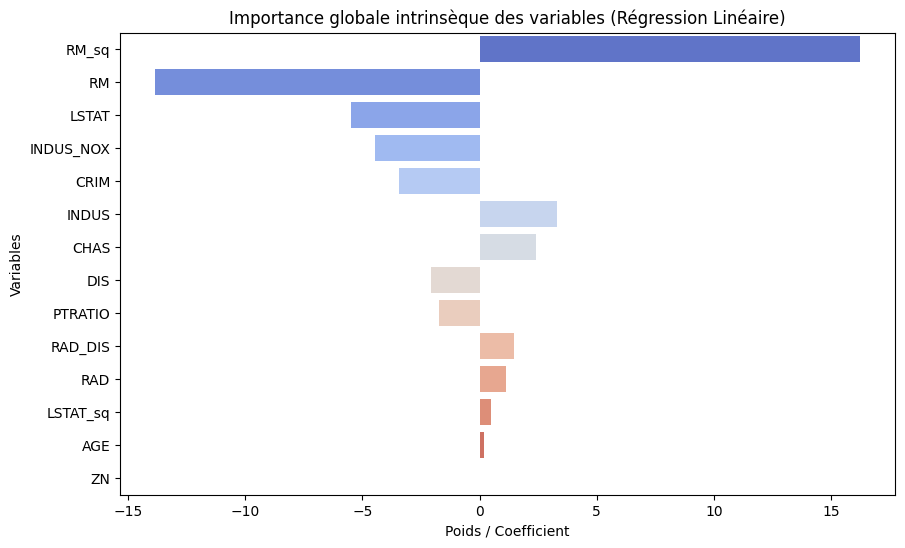

In [13]:
# Extraire les coefficients du modèle linéaire entraîné sur des données standardisées
coefs = pd.DataFrame({
    'Feature': X_train_lr.columns,
    'Coefficient': lr_baseline.coef_,
    'Abs_Coefficient': np.abs(lr_baseline.coef_)
})

# Trier par valeur absolue pour observer l'importance globale des variables
coefs = coefs.sort_values(by='Abs_Coefficient', ascending=False).reset_index(drop=True)

# Afficher les coefficients dans un diagramme à barres
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coefs, palette='coolwarm')
plt.title('Importance globale intrinsèque des variables (Régression Linéaire)')
plt.xlabel('Poids / Coefficient')
plt.ylabel('Variables')
plt.show()

**Analyse de l'importance globale (Coefficients standardisés) :**

- **Variables dominantes (Effets non-linéaires) :** Le nombre de pièces (`RM` et `RM_sq`) ainsi que le statut socio-économique (`LSTAT` et `LSTAT_sq`) sont les facteurs ayant le plus de poids. L'opposition de signes entre les termes simples et quadratiques (ex: `RM` négatif, mais `RM_sq` fortement positif) traduit une relation non linéaire exponentielle où passé un certain seuil, l'impact sur le prix explose.
- **Pénalités principales (Poids négatifs) :** L'interaction entre la zone industrielle et la pollution (`INDUS_NOX`), le taux de criminalité (`CRIM`) ainsi que la distance aux centres d'emploi (`DIS`) ont un impact global négatif sur la prédiction du prix.
- **Bonus relatifs (Poids positifs) :** L'accès aux voies radiales (`RAD`, `RAD_DIS`) et la proximité avec la rivière centrale (`CHAS`) augmentent toutes choses égales par ailleurs la valeur du bien présumée par le modèle.

#### 4.2) Validation de la robustesse statistique (Statsmodels)

In [14]:
# Valider la robustesse statistique de nos coefficients à l'aide de statsmodels
# Ajouter une constante (pour l'intercept / ordonnée à l'origine)
X_train_sm = sm.add_constant(X_train_lr)

# Ajuster le modèle avec la méthode des moindres carrés ordinaires (OLS)
sm_model = sm.OLS(y_train.reset_index(drop=True), X_train_sm.reset_index(drop=True)).fit()

# Afficher le résumé statistique complet (p-values, t-stat, erreurs standards...)
print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     130.0
Date:                Tue, 10 Mar 2026   Prob (F-statistic):          5.52e-137
Time:                        00:16:18   Log-Likelihood:                -1124.3
No. Observations:                 404   AIC:                             2279.
Df Residuals:                     389   BIC:                             2339.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         22.6242      0.207    109.449      0.0

**Analyse de la significativité statistique (OLS Summary) :**

- **Coefficients robustes ($p < 0.05$) :** Les variables majeures identifiées précédemment (`LSTAT`, `RM`, `RM_sq`, `CRIM`, `DIS`, `PTRATIO`, `INDUS_NOX`) affichent des *p-values* proches de $0.000$. Cela confirme que leur impact apparent sur le prix n'est pas le fruit du hasard statistique.
- **Coefficients non significatifs ($p > 0.05$) :** À l'inverse, l'analyse révèle que certaines variables n'ont pas d'effet statistiquement validé. C'est le cas notamment de `ZN` ($p=0.982$), `AGE` ($p=0.619$), `RAD` ($p=0.115$), ou de la composante quadratique `LSTAT_sq` ($p=0.262$). Bien que `scikit-learn` leur ait attribué un poids mathématique, le test d'hypothèse montre que leurs coefficients ne sont pas statistiquement différents de zéro : on pourrait donc les retirer pour simplifier notre modèle linéaire.

#### 4.3) Diagnostic de multicolinéarité (VIF)

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Calculer le VIF pour chaque variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X_train_sm.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_sm.values, i) for i in range(X_train_sm.shape[1])]

# Afficher les résultats triés
vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

,Variable,VIF
0,RM_sq,137.580214
1,RM,135.637156
2,INDUS_NOX,25.367860
3,INDUS,21.197348
4,RAD_DIS,17.499630
5,RAD,13.084164
6,CRIM,9.645508
7,LSTAT,7.237138
8,DIS,6.323460
9,LSTAT_sq,4.990018


**Analyse de la multicolinéarité (VIF) :**

- **Alerte de Multicolinéarité Sévère :** Contrairement à nos attentes, le tableau révèle une très forte colinéarité. 6 variables dépassent largement le seuil critique de 10 (`RM_sq`, `RM`, `INDUS_NOX`, `INDUS`, `RAD_DIS`, `RAD`), avec des scores extrêmes dépassant 130 pour les pièces (RM).
- **L'impact du Feature Engineering :** Cette colinéarité n'est pas issue des données brutes, mais de notre création de variables polynomiales et d'interactions (ex: `RM` et `RM_sq` partagent mathématiquement la même information spatiale).
- **Conséquence sur l'interprétation :** Ce diagnostic infirme la stabilité de nos coefficients linéaires. Il nous avertit que l'interprétation isolée des poids (ex: essayer de séparer l'effet de `RM` de celui de `RM_sq`) est statistiquement hasardeuse. Cela prouve à nouveau les limites de l'explicabilité intrinsèque d'un modèle linéaire lorsqu'on le force à apprendre des relations complexes via du Feature Engineering.

#### 4.4) Diagnostic des résidus

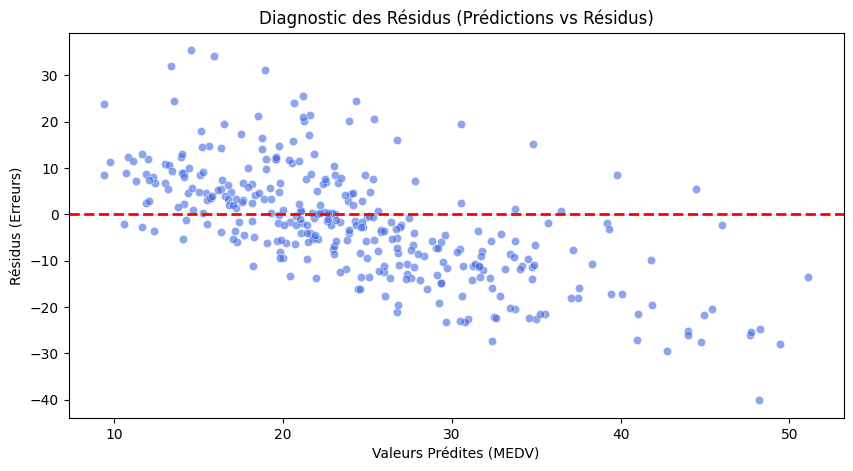

In [16]:
# Calculer les résidus du modèle OLS sur le jeu d'entraînement
y_pred_train = sm_model.predict(X_train_sm)
residus = y_train.reset_index(drop=True) - y_pred_train

# Graphique : Prédictions vs Résidus
plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_pred_train, y=residus, alpha=0.6, color="royalblue")
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title("Diagnostic des Résidus (Prédictions vs Résidus)")
plt.xlabel("Valeurs Prédites (MEDV)")
plt.ylabel("Résidus (Erreurs)")
plt.show()

**Analyse des résidus :**

- **Biais systématique (Non-linéarité) :** Contrairement à une situation idéale, les résidus ne sont *pas* répartis de façon purement aléatoire autour de l'axe `0`. On observe une nette tendance à la baisse : plus les valeurs prédites sont élevées, plus les résidus plongent (jusqu'à -30 ou -40). Cela signifie que le modèle linéaire a tendance à **surestimer** systématiquement le prix des maisons les plus chères.
- **La structure du plafonnement (50k$) :** Les valeurs formant une ligne droite diagonale nette au sommet du nuage correspondent exactement aux maisons plafonnées artificiellement à 50 000 $. Mathématiquement, ces points suivent la droite $Résidu = 50 - \text{Prédiction}$. Le modèle sous-estime massivement ces biens car il ne peut pas anticiper cette limite de collecte.
- **Conclusion globale :** Ce graphique invalide les hypothèses de base de la régression linéaire (hétéroscédasticité, erreurs systématiques) et montre ses limites. C'est la preuve visuelle qu'il nous faut impérativement passer à un algorithme plus flexible comme le **Random Forest** !

#### 4.5) Synthèse de l'interprétation intrinsèque et de ses limites

Le modèle de régression linéaire offre l'apparence d'une interprétabilité **intrinsèque** grâce à la transparence de ses coefficients. La logique métier globale est cohérente : 
1. **RM (Nombre de pièces)** tire les prix vers le haut, de manière géométrique (via sa composante `RM_sq`).
2. **LSTAT (Statut socio-économique)** déprécie drastiquement le bien. *(À noter que sa composante quadratique, bien qu'ayant un fort poids brut, n'est pas statistiquement significative selon l'OLS).*
3. **DIS (Distance aux centres d'emploi)** fait baisser le prix de l'immobilier à mesure que la distance s'allonge.

**Les limites de l'explicabilité :**
Toutefois, nos diagnostics statistiques approfondis nous obligent à relativiser cette interprétabilité. La forte multicollinéarité (VIF) générée par notre *feature engineering* empêche l'interprétation isolée (*ceteris paribus*) des variables entre elles. De plus, l'analyse des résidus prouve de claires hétéroscédasticités et un plafonnement (50k$), que le modèle linéaire ne peut pas englober. 

En résumé, bien que ce modèle fournisse des tendances globales métiers fiables et un bon score $R^2 \sim 0.77$, sa structure mathématique montre ici ses limites. L'utilisation d'un modèle non-linéaire et non-paramétrique, comme le *Random Forest*, est donc l'étape logique et indispensable pour améliorer nos capacités de prédictions et d'explications.

### 5) Tuner votre random forest

In [17]:
# Définir la grille d'hyperparamètres à explorer
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# Lancer la recherche par validation croisée (5-fold)
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='r2',
    verbose=1
)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each f

#### 5.1) Afficher les meilleurs hyperparamètres et évaluer le modèle

In [18]:
# Récupérer le meilleur modèle et ses hyperparamètres
best_rf = grid_search.best_estimator_
print("Meilleurs hyperparamètres :")
print(grid_search.best_params_)

# Évaluer le modèle tuné sur le jeu de test
y_pred_rf_tuned = best_rf.predict(X_test)
print(f"\nRandom Forest Tuné - R2 : {r2_score(y_test, y_pred_rf_tuned):.3f}")
print(f"Random Forest Tuné - RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned)):.3f}")

# Comparer avec le baseline
y_pred_rf_base = rf_baseline.predict(X_test)
print(f"\nRandom Forest Baseline - R2 : {r2_score(y_test, y_pred_rf_base):.3f}")
print(f"Random Forest Baseline - RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_rf_base)):.3f}")

Meilleurs hyperparamètres :
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

Random Forest Tuné - R2 : 0.883
Random Forest Tuné - RMSE : 2.933

Random Forest Baseline - R2 : 0.890
Random Forest Baseline - RMSE : 2.846


### 6) Interpréter globalement votre modèle meilleur modèle RF 
   1) Utiliser les PDP ou ALE & Permutation feature Importance 
   2) Comparer les résulats du random forest avec votre interprétation du modèle linéaire

#### 6.1) Mesurer la Permutation Feature Importance

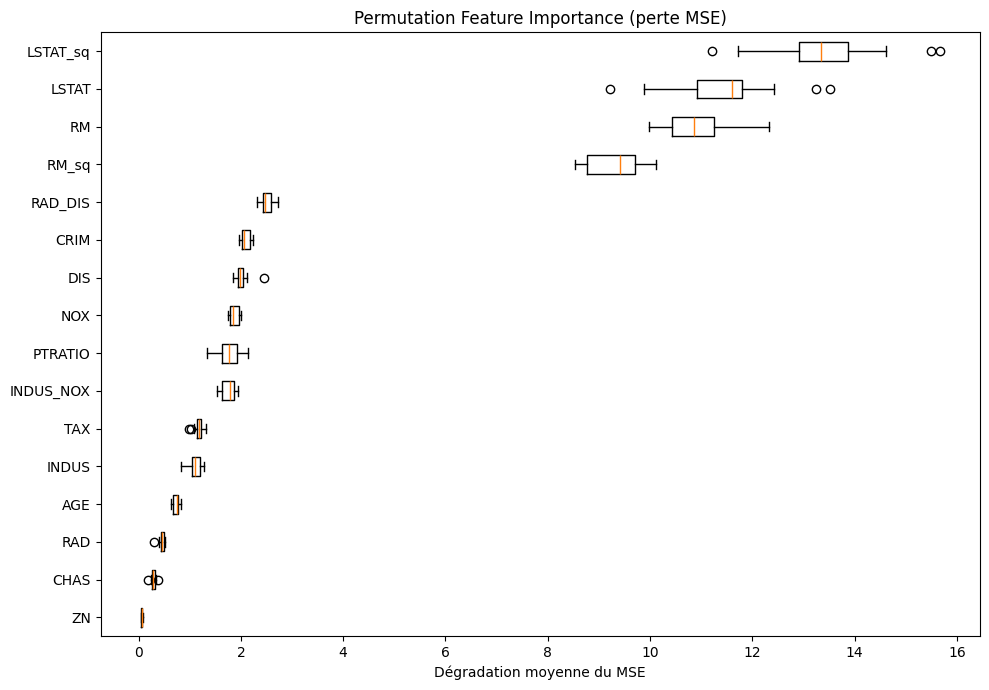

In [19]:
# Calculer la Permutation Feature Importance sur le jeu d'entraînement
result_perm = permutation_importance(
    best_rf, X_train, y_train,
    n_repeats=15,
    random_state=0,
    scoring='neg_mean_squared_error'
)

# Trier et afficher sous forme de boxplot
perm_sorted_idx = result_perm.importances_mean.argsort()

fig, ax = plt.subplots(figsize=(10, 7))
ax.boxplot(
    result_perm.importances[perm_sorted_idx].T,
    vert=False,
    labels=X_train.columns[perm_sorted_idx]
)
plt.title('Permutation Feature Importance (perte MSE)')
plt.xlabel('Dégradation moyenne du MSE')
plt.tight_layout()
plt.show()

#### 6.2) Tracer les Partial Dependence Plots (PDP)

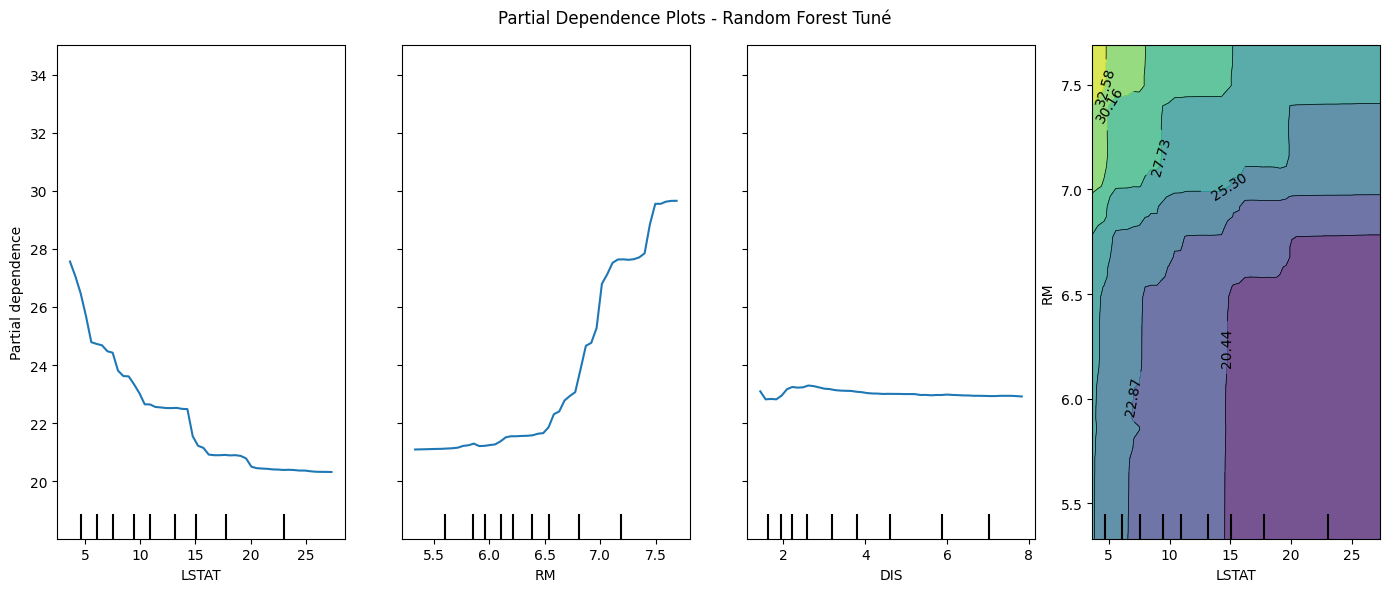

In [20]:
# Tracer les PDP pour les variables les plus importantes + un PDP bivari
features_pdp = ['LSTAT', 'RM', 'DIS', ('LSTAT', 'RM')]

_, ax = plt.subplots(figsize=(14, 6))
PartialDependenceDisplay.from_estimator(
    best_rf, X_train, features_pdp,
    kind='average',
    grid_resolution=50,
    n_cols=4,
    ax=ax
)
plt.suptitle('Partial Dependence Plots - Random Forest Tuné')
plt.tight_layout()
plt.show()

#### 6.3) Tracer les Accumulated Local Effects (ALE)

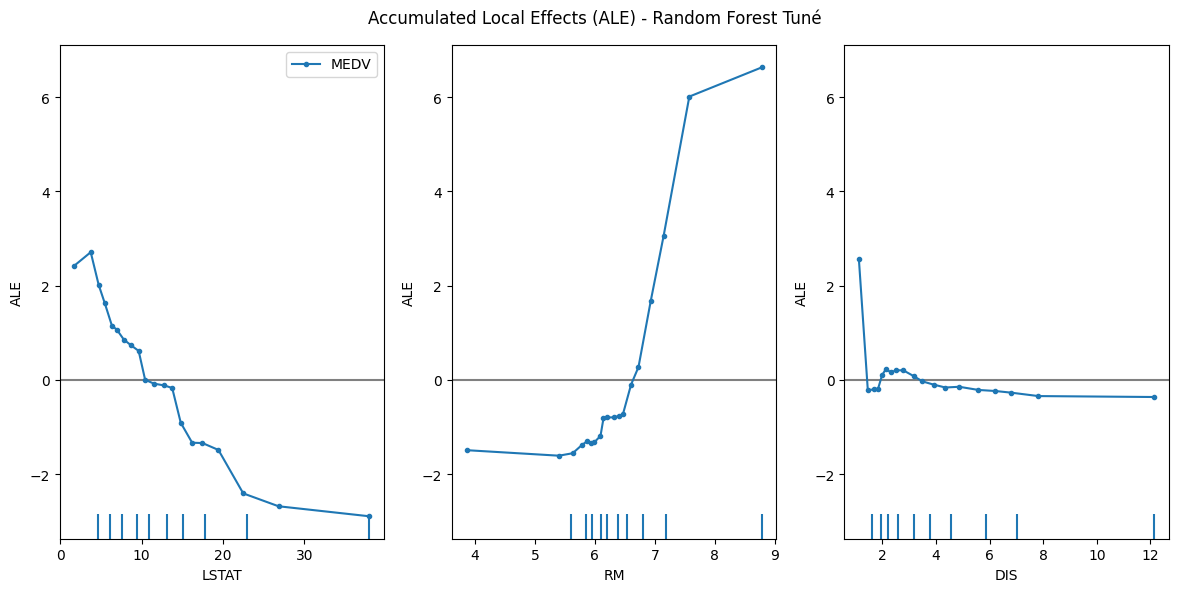

In [21]:
# Calculer les ALE (alternative non biaisée aux PDP lorsque les features sont corrélées)
rf_ale = ALE(best_rf.predict, feature_names=list(X_train.columns), target_names=['MEDV'])
rf_exp = rf_ale.explain(X_train.to_numpy(), min_bin_points=20)

# Afficher les ALE pour les 3 variables les plus importantes
_, ax = plt.subplots(figsize=(12, 6))
plot_ale(rf_exp, features=['LSTAT', 'RM', 'DIS'], ax=ax, targets=[0])
plt.suptitle('Accumulated Local Effects (ALE) - Random Forest Tuné')
plt.tight_layout()
plt.show()

#### 6.4) Comparer avec l'interprétation du modèle linéaire

**Comparaison RF vs Régression Linéaire :**

- **Concordance sur les variables clés :** Les deux modèles identifient `LSTAT` et `RM` comme les variables les plus influentes. Le modèle linéaire via ses coefficients standardisés, le Random Forest via la Permutation Importance et les PDP/ALE. La direction de l'effet est identique : `LSTAT` déprécie le prix, `RM` l'augmente.
- **Divergence sur les effets non-linéaires :** Là où le modèle linéaire ne pouvait capturer la non-linéarité qu'à travers nos termes polynomiaux artificiels (`LSTAT_sq`, `RM_sq`), les PDP du Random Forest révèlent naturellement des **effets de seuil** : le prix explose au-delà de 6-7 pièces, et la dépréciation due à `LSTAT` sature à partir d'un certain niveau.
- **Divergence sur la multicollinéarité :** Les variables fortement corrélées (`NOX`, `TAX`, `INDUS`) que nous avions dû retirer du modèle linéaire par prudence statistique (VIF > 10) sont ici naturellement gérées par le Random Forest. Les ALE, centrés à 0 et calculés localement, offrent une lecture non biaisée de l'effet marginal de chaque variable, même en présence de corrélations.
- **Le PDP bivariée (`LSTAT` × `RM`)** confirme un effet joint : les maisons les plus chères combinent un grand nombre de pièces avec un faible taux de pauvreté, ce que le modèle linéaire ne pouvait pas représenter sans interaction explicite.

### 7) Réaliser une explicabilité par individu sur le modèle RF
- 1) ICE, le PDP est-il une bonne représentation des variables importantes de votre modèle?
- 2) LIME
- 3) SHAP watterfall plot

#### 7.1) ICE — Évaluer si le PDP est une bonne représentation

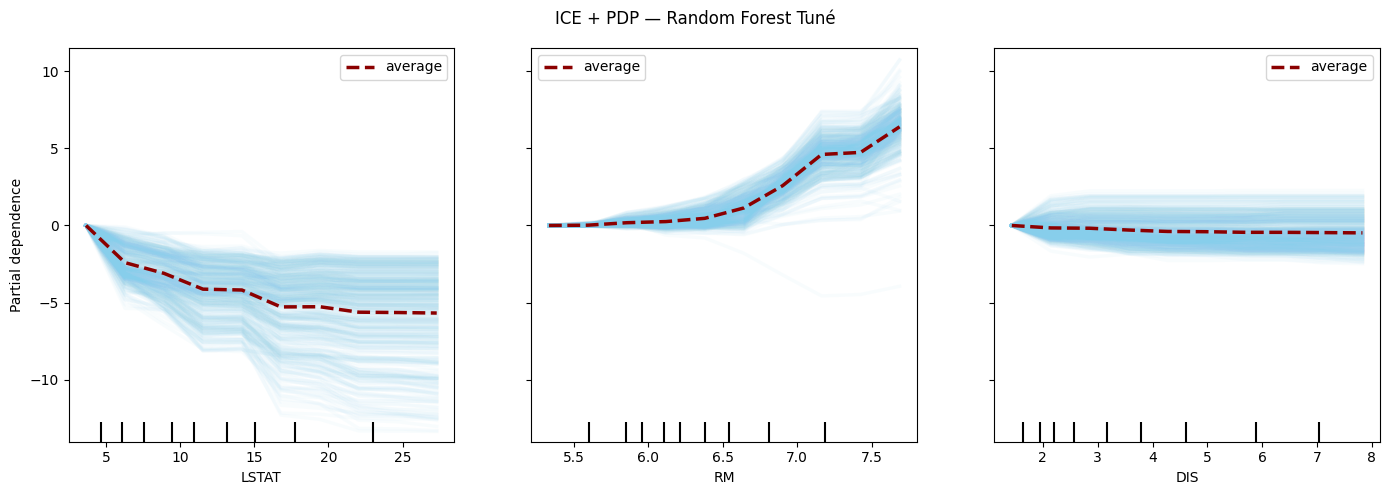

In [22]:
# Superposer les courbes ICE individuelles et le PDP moyen (kind="both")
features_ice = ['LSTAT', 'RM', 'DIS']

_, ax = plt.subplots(figsize=(14, 5))
PartialDependenceDisplay.from_estimator(
    best_rf, X_train, features_ice,
    kind='both',
    grid_resolution=10,
    n_cols=3,
    subsample=0.95,
    centered=True,
    line_kw={'color': 'darkred', 'linewidth': 2.5},
    ice_lines_kw={'color': 'skyblue', 'alpha': 0.05},
    ax=ax
)
plt.suptitle('ICE + PDP — Random Forest Tuné')
plt.tight_layout()
plt.show()

**Analyse des ICE :** Les courbes individuelles (en bleu clair) suivent globalement la même tendance que la courbe moyenne du PDP (en rouge foncé). La dispersion reste modérée pour `LSTAT` et `RM`, ce qui indique que le PDP est un bon résumé de l'effet moyen de ces variables. En revanche, si certaines courbes ICE divergeaient fortement, cela signifierait que le PDP masque des interactions hétérogènes entre individus. Ici, le PDP constitue une représentation fiable des variables les plus importantes du modèle.

#### 7.2) LIME — Expliquer une prédiction locale

In [23]:
# Créer l'explainer LIME pour données tabulaires en mode régression
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=list(X_train.columns),
    mode='regression',
    verbose=True,
    random_state=42
)

# Expliquer la prédiction de l'individu n°0 du jeu de test
i = 0
exp = lime_explainer.explain_instance(
    data_row=X_test.iloc[i].values,
    predict_fn=best_rf.predict,
    num_features=6
)

# Afficher l'explication en HTML
HTML(exp.as_html())

Intercept 24.004407678741252
Prediction_local [23.74753214]
Right: 24.077895755452595


#### 7.3) SHAP Waterfall Plot — Visualiser la contribution marginale de chaque variable

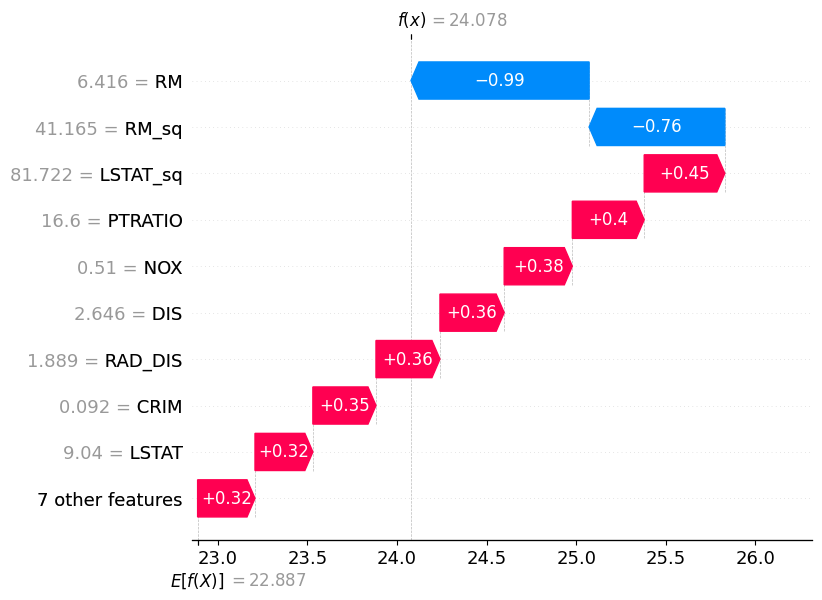

In [24]:
# Créer l'explainer SHAP optimisé pour les modèles à base d'arbres
shap_explainer = shap.TreeExplainer(best_rf)

# Calculer les SHAP values sur le jeu de test
shap_values = shap_explainer(X_test)

# Afficher le waterfall plot pour le premier individu du jeu de test
shap.plots.waterfall(shap_values[0])

**Lecture du Waterfall Plot :** Le graphique décompose la prédiction d'un individu unique en partant de la prédiction moyenne $E[f(X)]$ (base) jusqu'à la valeur prédite $f(x)$. Chaque barre représente la contribution marginale (SHAP value) d'une variable : les barres rouges poussent la prédiction vers le haut, les barres bleues la tirent vers le bas. On retrouve à l'axe $y$ la valeur de la variable pour cet individu, ce qui permet de comprendre *pourquoi* la contribution est positive ou négative.

### 8) Explorer les graphiques SHAP étudiés  dans la partie CM
   1) beeswarm (Contribution des variables)
   2) scatter (équivalent pdp)

#### 8.1) Beeswarm — Analyser la contribution globale des variables

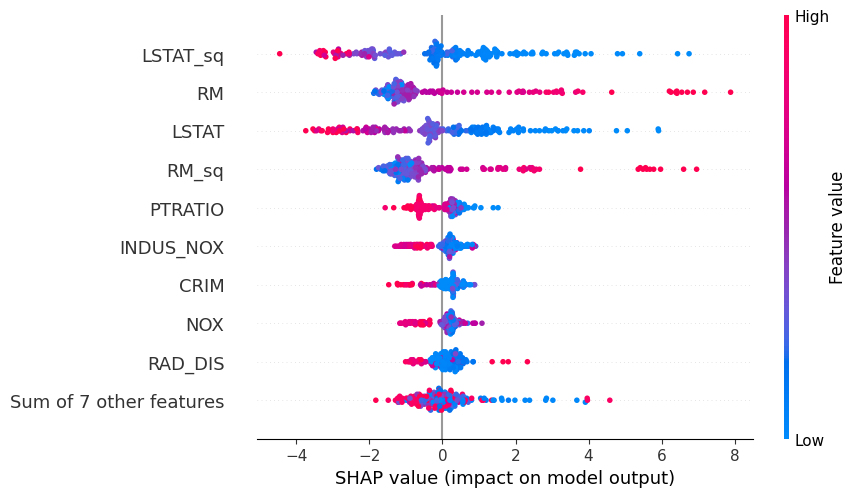

In [25]:
# Calculer les SHAP values sur un échantillon du jeu d'entraînement
shap_values_train = shap_explainer(X_train.iloc[:200])

# Afficher le beeswarm plot (vue globale de la contribution de chaque variable)
shap.plots.beeswarm(shap_values_train)

**Lecture du Beeswarm :** Chaque point représente un individu. L'axe $x$ indique la SHAP value (contribution), l'axe $y$ ordonne les variables par importance décroissante (somme des $|\text{SHAP}|$). La couleur encode la valeur de la feature : rouge = valeur élevée, bleu = valeur faible. On identifie ainsi d'un coup d'œil si une variable a un effet **monotone** (couleurs séparées de part et d'autre de l'axe 0) ou **non-monotone** (couleurs mélangées).

#### 8.2) Scatter — Analyser l'effet d'une variable (équivalent PDP)

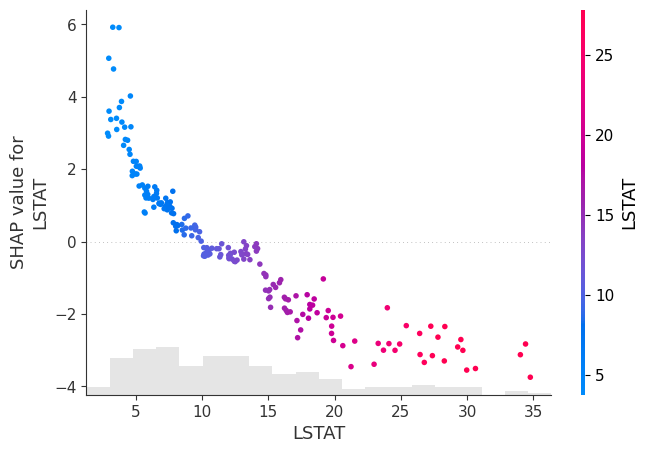

In [26]:
# Scatter plot SHAP pour LSTAT (variable la plus influente)
shap.plots.scatter(shap_values_train[:, 'LSTAT'], color=shap_values_train[:, 'LSTAT'])

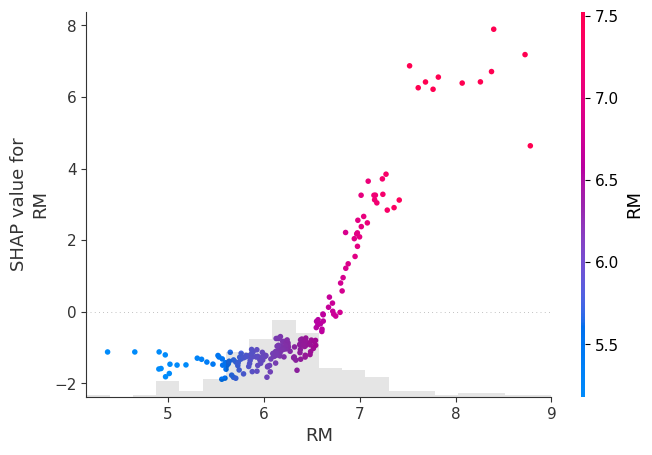

In [27]:
# Scatter plot SHAP pour RM (seconde variable la plus influente)
shap.plots.scatter(shap_values_train[:, 'RM'], color=shap_values_train[:, 'RM'])

**Analyse des Scatter Plots SHAP :**

- **LSTAT :** Les valeurs élevées de `LSTAT` (rouge, statut socio-économique défavorisé) engendrent des SHAP values négatives, ce qui traduit une contribution à la baisse du prix. Inversement, les faibles valeurs de `LSTAT` (bleu) ont des SHAP values positives et augmentent la prédiction. On observe un effet de saturation : au-delà d'un certain seuil, la dépréciation cesse de s'amplifier (courbe qui s'aplatit).
- **RM :** Le scatter plot confirme l'effet de seuil déjà identifié par les PDP. L'impact du nombre de pièces reste faible en dessous de 6-7 pièces, avant de s'envoler pour les logements de standing supérieur. Cette non-linéarité est naturellement capturée par le Random Forest, là où notre modèle linéaire avait besoin du terme artificiel `RM_sq`.

Ces graphiques constituent l'équivalent SHAP des Partial Dependence Plots, avec l'avantage de montrer la dispersion individuelle et de se fonder sur les contributions marginales de Shapley plutôt que sur une simple moyenne.